In [3]:
import numpy as np
import matplotlib.pyplot as plt

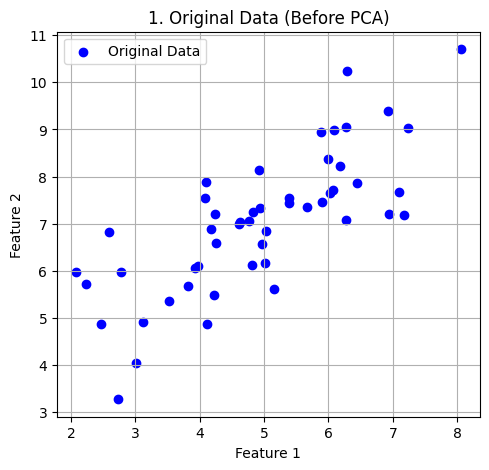

In [4]:
# Generate sample 2D data
np.random.seed(0)  # for reproducibility
num_points = 50
X = np.random.multivariate_normal(mean=[5, 7], cov=[[2, 1.5], [1.5, 2]], size=num_points)

# --- 1. Visualize Original Data ---
plt.figure(figsize=(12, 5))  # Adjust figure size for side-by-side plots

plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
plt.scatter(X[:, 0], X[:, 1], color='blue', label='Original Data')
plt.title('1. Original Data (Before PCA)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)

In [ ]:
X

array([[ 2.46629949,  4.8664567 ],
       [ 2.58480475,  6.82569795],
       [ 3.01809194,  4.04081406],
       [ 3.81882977,  5.66747256],
       [ 4.93124646,  7.34184496],
       [ 4.08231151,  7.53658502],
       [ 3.93240421,  6.05407923],
       [ 4.24598697,  6.5796613 ],
       [ 3.1260983 ,  4.92094003],
       [ 5.01289823,  6.15880249],
       [ 8.05047878, 10.70409737],
       [ 4.22754091,  5.48537589],
       [ 2.7245797 ,  3.27021403],
       [ 5.0330591 ,  6.84587525],
       [ 2.23764431,  5.70700308],
       [ 4.60594256,  6.98410508],
       [ 7.16482839,  7.18403192],
       [ 5.38207003,  7.538419  ],
       [ 2.77128848,  5.97366833],
       [ 5.66353659,  7.36123384],
       [ 7.09711416,  7.67709622],
       [ 6.2817956 , 10.23257099],
       [ 5.89324361,  7.45516931],
       [ 6.26854731,  9.04603766],
       [ 7.24135631,  9.02861603],
       [ 5.99113967,  8.37804216],
       [ 6.26604777,  7.08541559],
       [ 4.82311565,  7.25144752],
       [ 4.76077004,

In [5]:
# prompt: X_centered shape

X.shape


(50, 2)

In [ ]:
# --- 2. PCA Calculation ---
mean = np.mean(X, axis=0)
X_centered = X - mean  # Center the data
cov_matrix = np.cov(X_centered.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues and eigenvectors
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

pc1 = eigenvectors[:, 0]  # First principal component
X_projected = X_centered.dot(pc1).reshape(-1, 1)
X_reconstructed = X_projected.dot(pc1.reshape(1, -1)) + mean

# Output eigenvalues and eigenvectors (optional)
print(f"Eigenvalues: {eigenvalues}")
print(f"Eigenvectors: \n{eigenvectors}")

Eigenvalues: [3.78714225 0.49312483]
Eigenvectors: 
[[-0.69739208 -0.71668981]
 [-0.71668981  0.69739208]]


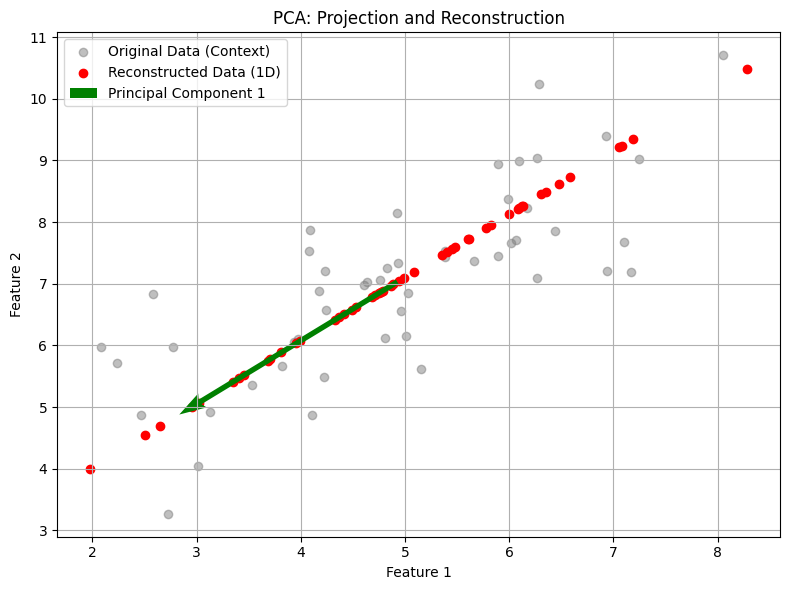

In [ ]:
# --- Visualize Data After PCA (Projection and Reconstruction) ---
plt.figure(figsize=(8, 6))  # Adjust figure size as needed

# Original data points (for context)
plt.scatter(X[:, 0], X[:, 1], color='gray', alpha=0.5, label='Original Data (Context)')

# Reconstructed data points
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], color='red', label='Reconstructed Data (1D)')

# Principal component vector
scale = 3  # Adjust for vector length on plot
plt.quiver(mean[0], mean[1], pc1[0]*scale, pc1[1]*scale, angles='xy', scale_units='xy', scale=1, color='green', label='Principal Component 1')

plt.title('PCA: Projection and Reconstruction')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()